In [4]:
import json
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("../..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

SCORING_ROOT = Path("/data/energy-system-preprocessing/scoring")
MODEL_SCORING  = SCORING_ROOT / "models"
PAPILO_SCORING = SCORING_ROOT / "papilo"

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})


def parse_name(stem: str) -> dict:
    """Parse stem like 'r10_res168_f0.0000_t0.0192-k10-col-soed-vd200'."""
    model_name = stem.split("-k")[0]
    m = re.match(r"r(\d+)_res(\d+)_f([\d.]+)_t([\d.]+)", model_name)
    return {
        "model": model_name,
        "k":   int(m.group(1)),
        "res": int(m.group(2)),
        "f":   float(m.group(3)),
        "t":   float(m.group(4)),
    }


def load_folder(folder: Path) -> pd.DataFrame:
    rows = []
    for f in sorted(folder.glob("*.json")):
        data = json.loads(f.read_text())
        info = parse_name(f.stem)
        sizes = data["block_sizes"]
        block_rows = sum(sizes)
        total_rows = block_rows + data["coupling_rows"]
        rows.append({
            **info,
            "n_blocks":       data["n_blocks"],
            "block_rows":     block_rows,
            "total_rows":     total_rows,
            "coupling_rows":  data["coupling_rows"],
            "coupling_cols":  data["coupling_cols"],
            "coupling_row_frac": data["coupling_rows"] / total_rows if total_rows else 0,
            "whitescore":     data["whitescore"],
            "score":          data["score"],
            "block_size_cv":  np.std(sizes) / np.mean(sizes) if sizes else 0,
        })
    return pd.DataFrame(rows)


orig   = load_folder(MODEL_SCORING).assign(source="original")
papilo = load_folder(PAPILO_SCORING).assign(source="papilo")
df     = pd.concat([orig, papilo], ignore_index=True)

print(f"Loaded {len(orig)} original, {len(papilo)} papilo records")
df.head()

Loaded 440 original, 440 papilo records


,model,k,res,f,t,n_blocks,block_rows,total_rows,coupling_rows,coupling_cols,coupling_row_frac,whitescore,score,block_size_cv,source
0,r10_res168_f0.0000_t0.0192,10,168,0.00,0.0192,10,133,148,15,0,0.101351,0.900806,90.080364,0.150564,original
1,r10_res168_f0.0000_t0.0833,10,168,0.00,0.0833,10,475,532,57,0,0.107143,0.900113,90.007077,0.046364,original
2,r10_res168_f0.0000_t1.0000,10,168,0.00,1.0000,10,4467,5140,673,0,0.130934,0.899967,89.653387,0.168687,original
3,r10_res168_f0.2500_t0.5000,10,168,0.25,0.5000,10,1233,1396,163,0,0.116762,0.899985,89.963631,0.101041,original
4,r10_res168_f0.5000_t1.0000,10,168,0.50,1.0000,10,2344,2644,300,0,0.113464,0.899995,89.878345,0.184823,original


/tmp/ipykernel_1343893/3550885702.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = cm.get_cmap("tab10", len(ks))


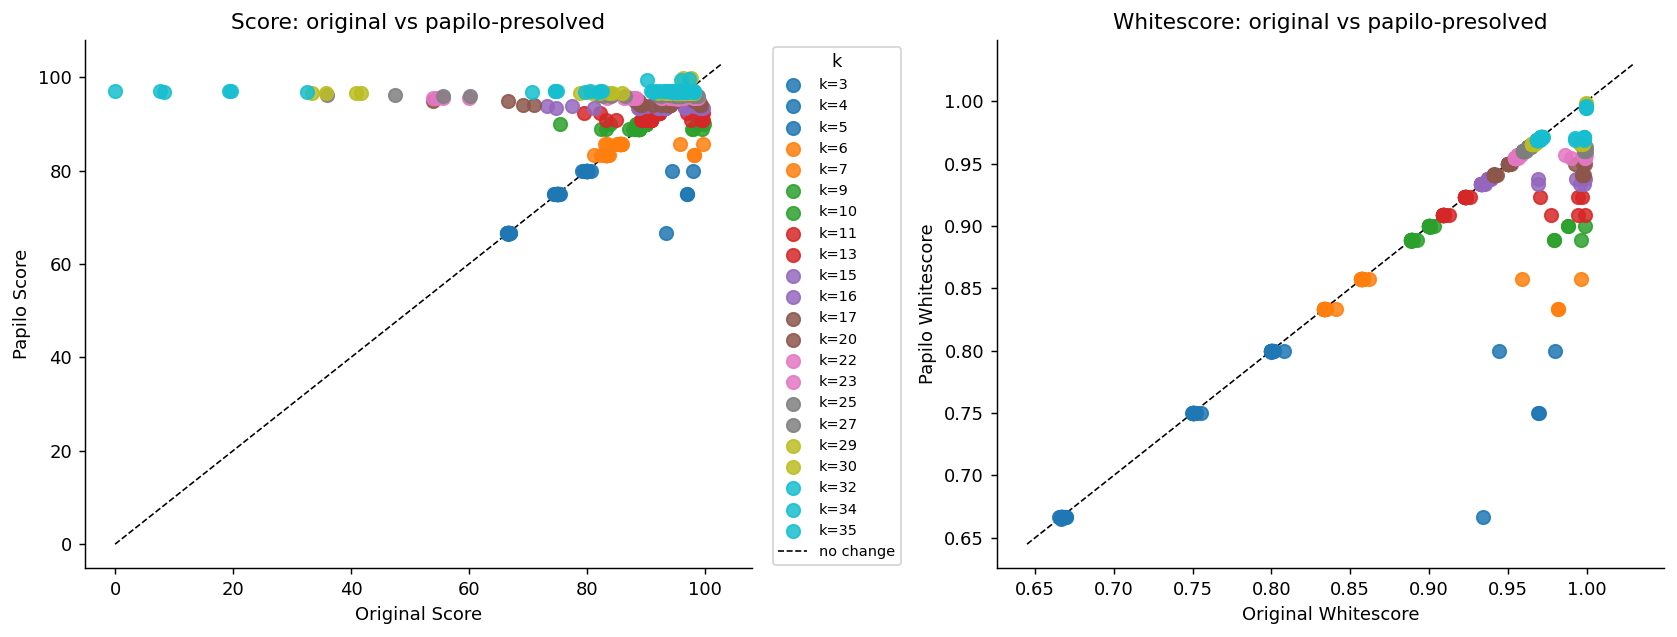

In [5]:
# --- Score scatter: original vs papilo ---
# Each point is one model; colour = k; diagonal = no change.
# Points above the line → presolving improved the decomposition.

keys = ["model", "k", "res", "f", "t"]
merged = orig.merge(papilo, on=keys, suffixes=("_orig", "_papilo"))

ks     = sorted(merged["k"].unique())
cmap   = cm.get_cmap("tab10", len(ks))
colors = {k: cmap(i) for i, k in enumerate(ks)}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, label in [
    (axes[0], "score",      "Score"),
    (axes[1], "whitescore", "Whitescore"),
]:
    for k, grp in merged.groupby("k"):
        ax.scatter(
            grp[f"{metric}_orig"], grp[f"{metric}_papilo"],
            color=colors[k], label=f"k={k}", alpha=0.85, s=55, zorder=3,
        )
    lo = min(merged[f"{metric}_orig"].min(), merged[f"{metric}_papilo"].min()) * 0.97
    hi = max(merged[f"{metric}_orig"].max(), merged[f"{metric}_papilo"].max()) * 1.03
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.9, label="no change")
    ax.set_xlabel(f"Original {label}")
    ax.set_ylabel(f"Papilo {label}")
    ax.set_title(f"{label}: original vs papilo-presolved")

axes[0].legend(title="k", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

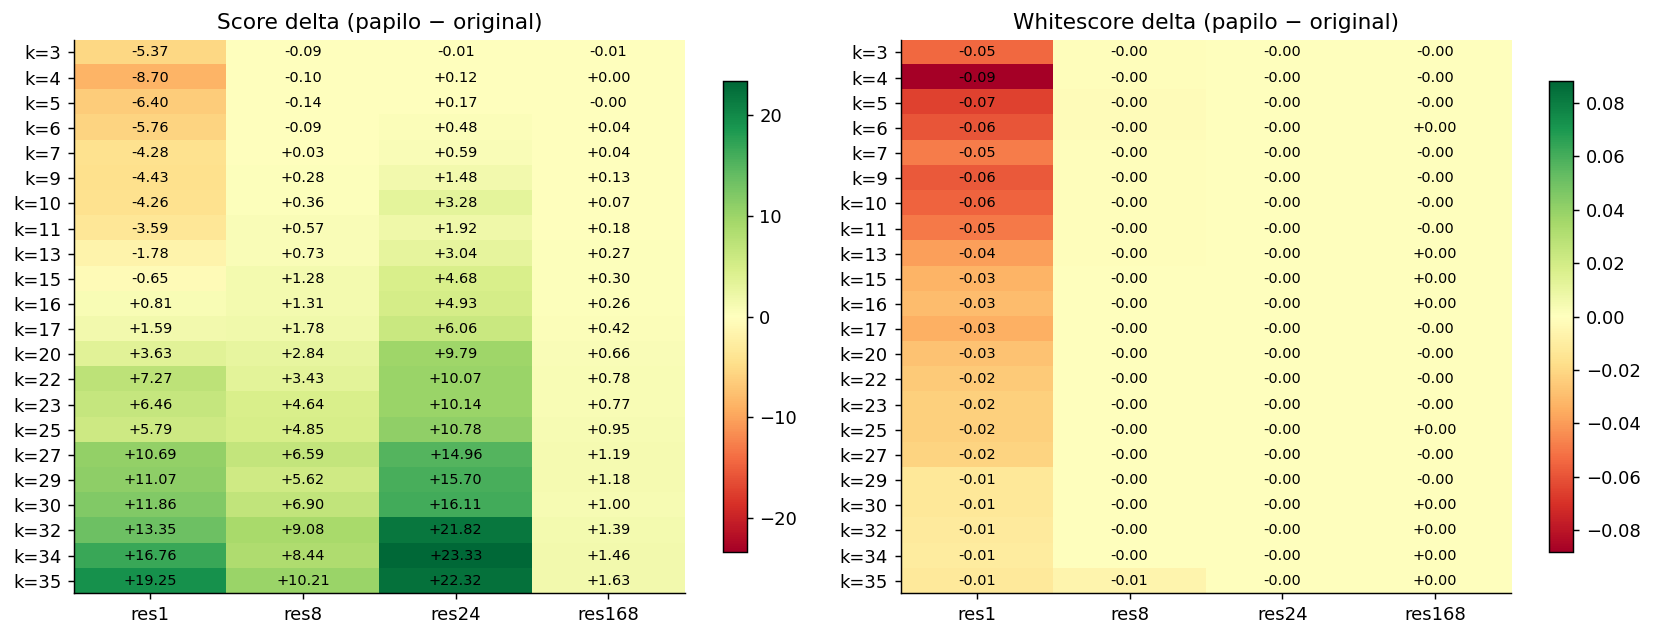

In [6]:
# --- Score delta heatmap: k × resolution ---
# Colour = mean(papilo − original).  Green → presolving helps; red → hurts.

merged["score_delta"]      = merged["score_papilo"]      - merged["score_orig"]
merged["whitescore_delta"] = merged["whitescore_papilo"] - merged["whitescore_orig"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in [
    (axes[0], "score_delta",      "Score delta (papilo − original)"),
    (axes[1], "whitescore_delta", "Whitescore delta (papilo − original)"),
]:
    pivot = merged.groupby(["k", "res"])[col].mean().unstack("res")
    vmax  = np.abs(pivot.values).max()
    im    = ax.imshow(pivot.values, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"res{r}" for r in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"k={k}" for k in pivot.index])
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            ax.text(j, i, f"{pivot.values[i, j]:+.2f}",
                    ha="center", va="center", fontsize=8)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.85)

fig.tight_layout()
plt.show()

/tmp/ipykernel_1343893/3321380980.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  res_cmap    = cm.get_cmap("Set2", len(resolutions))


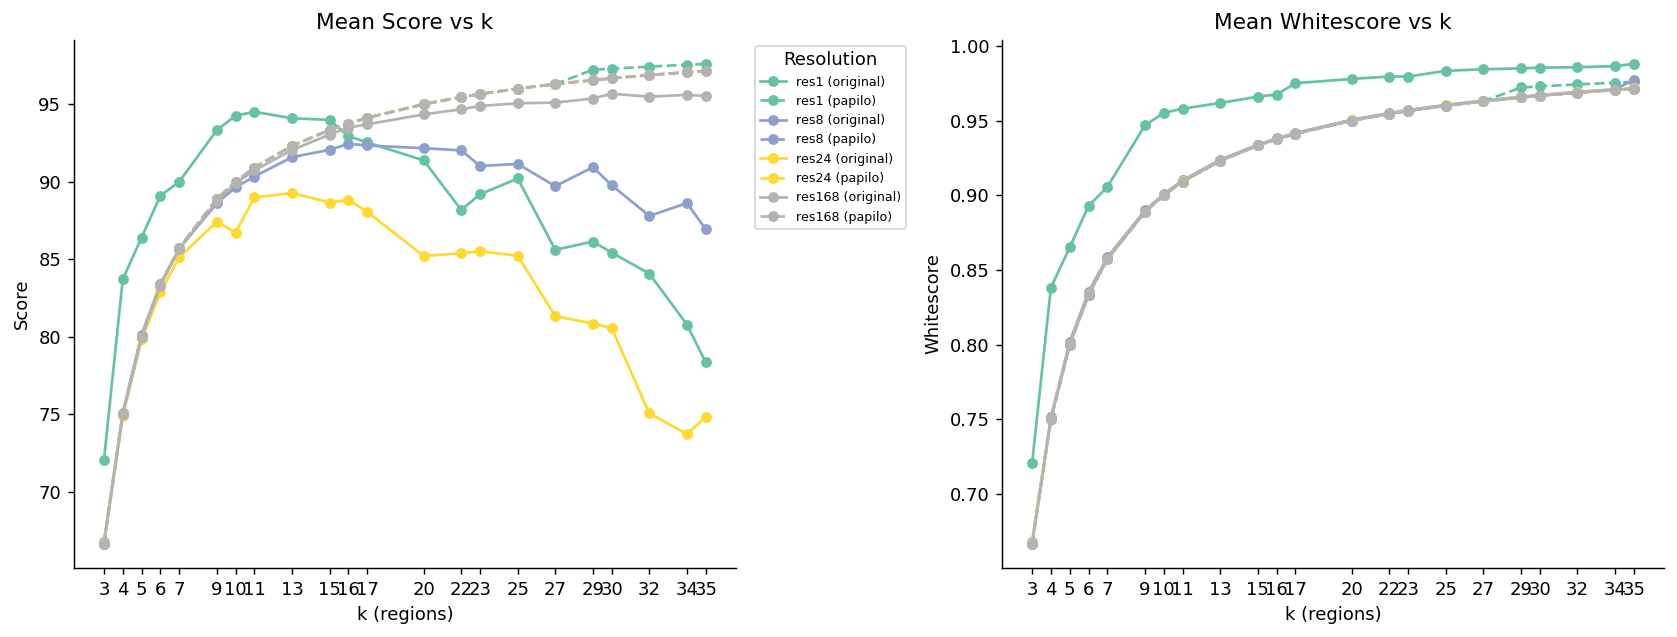

In [7]:
# --- Score & whitescore vs k, by resolution ---
# Solid = original, dashed = papilo.  Shows how decomposition quality scales with k.

resolutions = sorted(df["res"].unique())
ks_ordered  = sorted(df["k"].unique())
res_cmap    = cm.get_cmap("Set2", len(resolutions))
res_colors  = {r: res_cmap(i) for i, r in enumerate(resolutions)}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, label in [
    (axes[0], "score",      "Score"),
    (axes[1], "whitescore", "Whitescore"),
]:
    for res in resolutions:
        for source, ls in [("original", "-"), ("papilo", "--")]:
            sub = (
                df[(df["res"] == res) & (df["source"] == source)]
                .groupby("k")[metric].mean()
                .reindex(ks_ordered)
            )
            ax.plot(
                sub.index, sub.values,
                color=res_colors[res], linestyle=ls, marker="o", markersize=5,
                label=f"res{res} ({source})",
            )
    ax.set_xlabel("k (regions)")
    ax.set_ylabel(label)
    ax.set_title(f"Mean {label} vs k")
    ax.set_xticks(ks_ordered)

axes[0].legend(title="Resolution", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
fig.tight_layout()
plt.show()

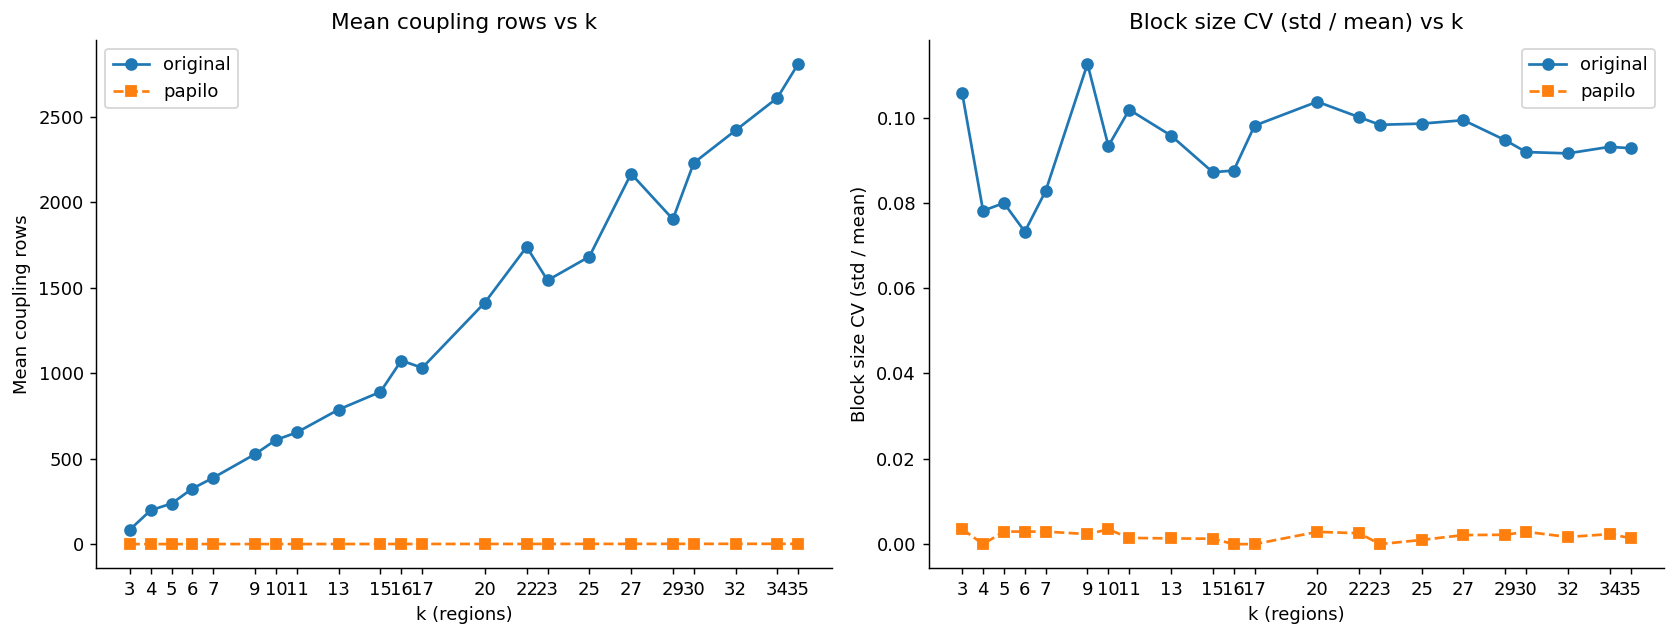

In [8]:
# --- Coupling rows & block size imbalance vs k ---
# Coupling rows: fewer = cleaner decomposition.
# Block size CV (std/mean): lower = more balanced blocks across regions.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, label in [
    (axes[0], "coupling_rows", "Mean coupling rows"),
    (axes[1], "block_size_cv", "Block size CV (std / mean)"),
]:
    for source, ls, marker in [("original", "-", "o"), ("papilo", "--", "s")]:
        sub = (
            df[df["source"] == source]
            .groupby("k")[metric].mean()
            .reindex(ks_ordered)
        )
        ax.plot(sub.index, sub.values, linestyle=ls, marker=marker,
                markersize=6, label=source)
    ax.set_xlabel("k (regions)")
    ax.set_ylabel(label)
    ax.set_title(f"{label} vs k")
    ax.set_xticks(ks_ordered)
    ax.legend()

fig.tight_layout()
plt.show()

/tmp/ipykernel_1343893/401721124.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = cm.get_cmap("tab10", len(ks))


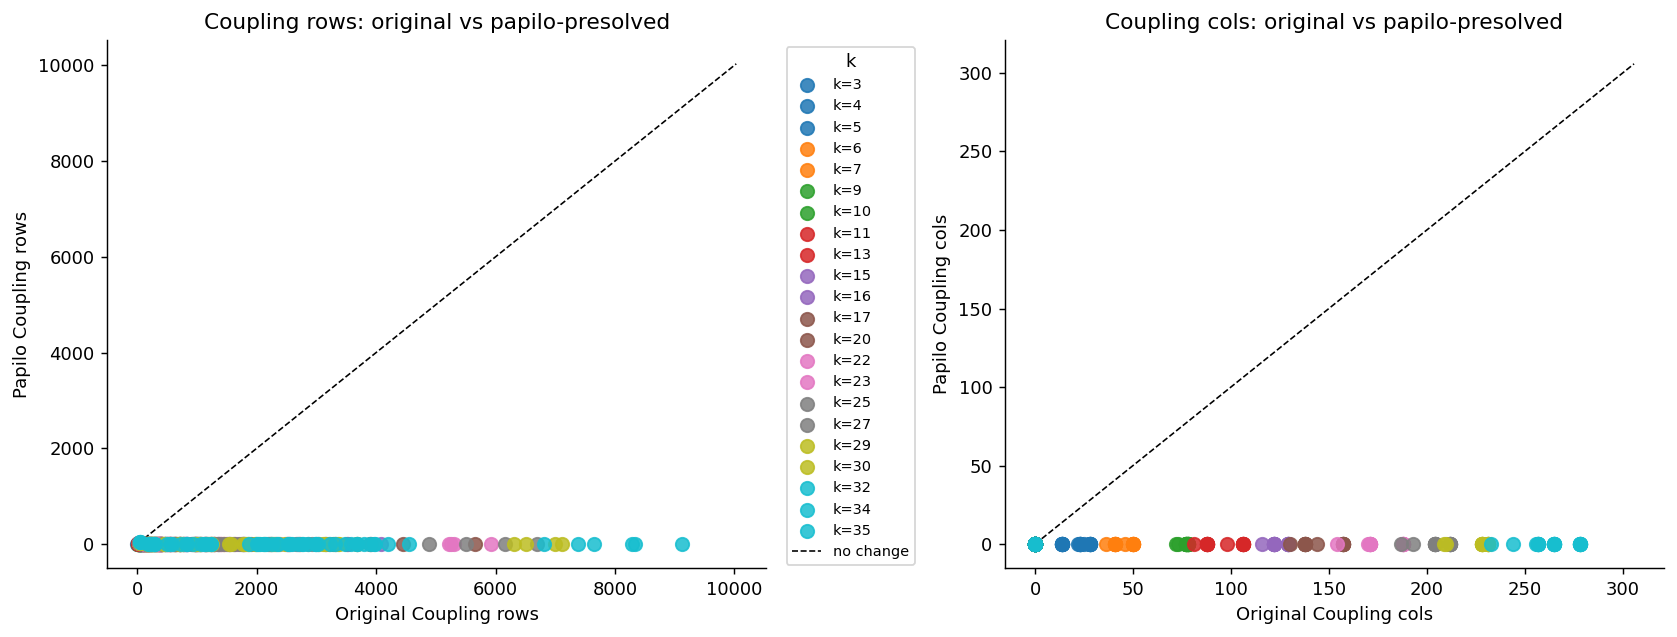

In [9]:
# --- Coupling rows & cols: original vs papilo (paired scatter) ---
# Each point is one model.  Diagonal = no change.
# coupling_cols are linking-variable columns (partition 1 in pipstools).

keys   = ["model", "k", "res", "f", "t"]
merged = orig.merge(papilo, on=keys, suffixes=("_orig", "_papilo"))

ks     = sorted(merged["k"].unique())
cmap   = cm.get_cmap("tab10", len(ks))
colors = {k: cmap(i) for i, k in enumerate(ks)}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, label in [
    (axes[0], "coupling_rows", "Coupling rows"),
    (axes[1], "coupling_cols", "Coupling cols"),
]:
    for k, grp in merged.groupby("k"):
        ax.scatter(
            grp[f"{metric}_orig"], grp[f"{metric}_papilo"],
            color=colors[k], label=f"k={k}", alpha=0.85, s=55, zorder=3,
        )
    lo = min(merged[f"{metric}_orig"].min(), merged[f"{metric}_papilo"].min()) * 0.9
    hi = max(merged[f"{metric}_orig"].max(), merged[f"{metric}_papilo"].max()) * 1.1
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.9, label="no change")
    ax.set_xlabel(f"Original {label}")
    ax.set_ylabel(f"Papilo {label}")
    ax.set_title(f"{label}: original vs papilo-presolved")

axes[0].legend(title="k", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

/tmp/ipykernel_1343893/3083684199.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  res_cmap    = cm.get_cmap("Set2", len(resolutions))


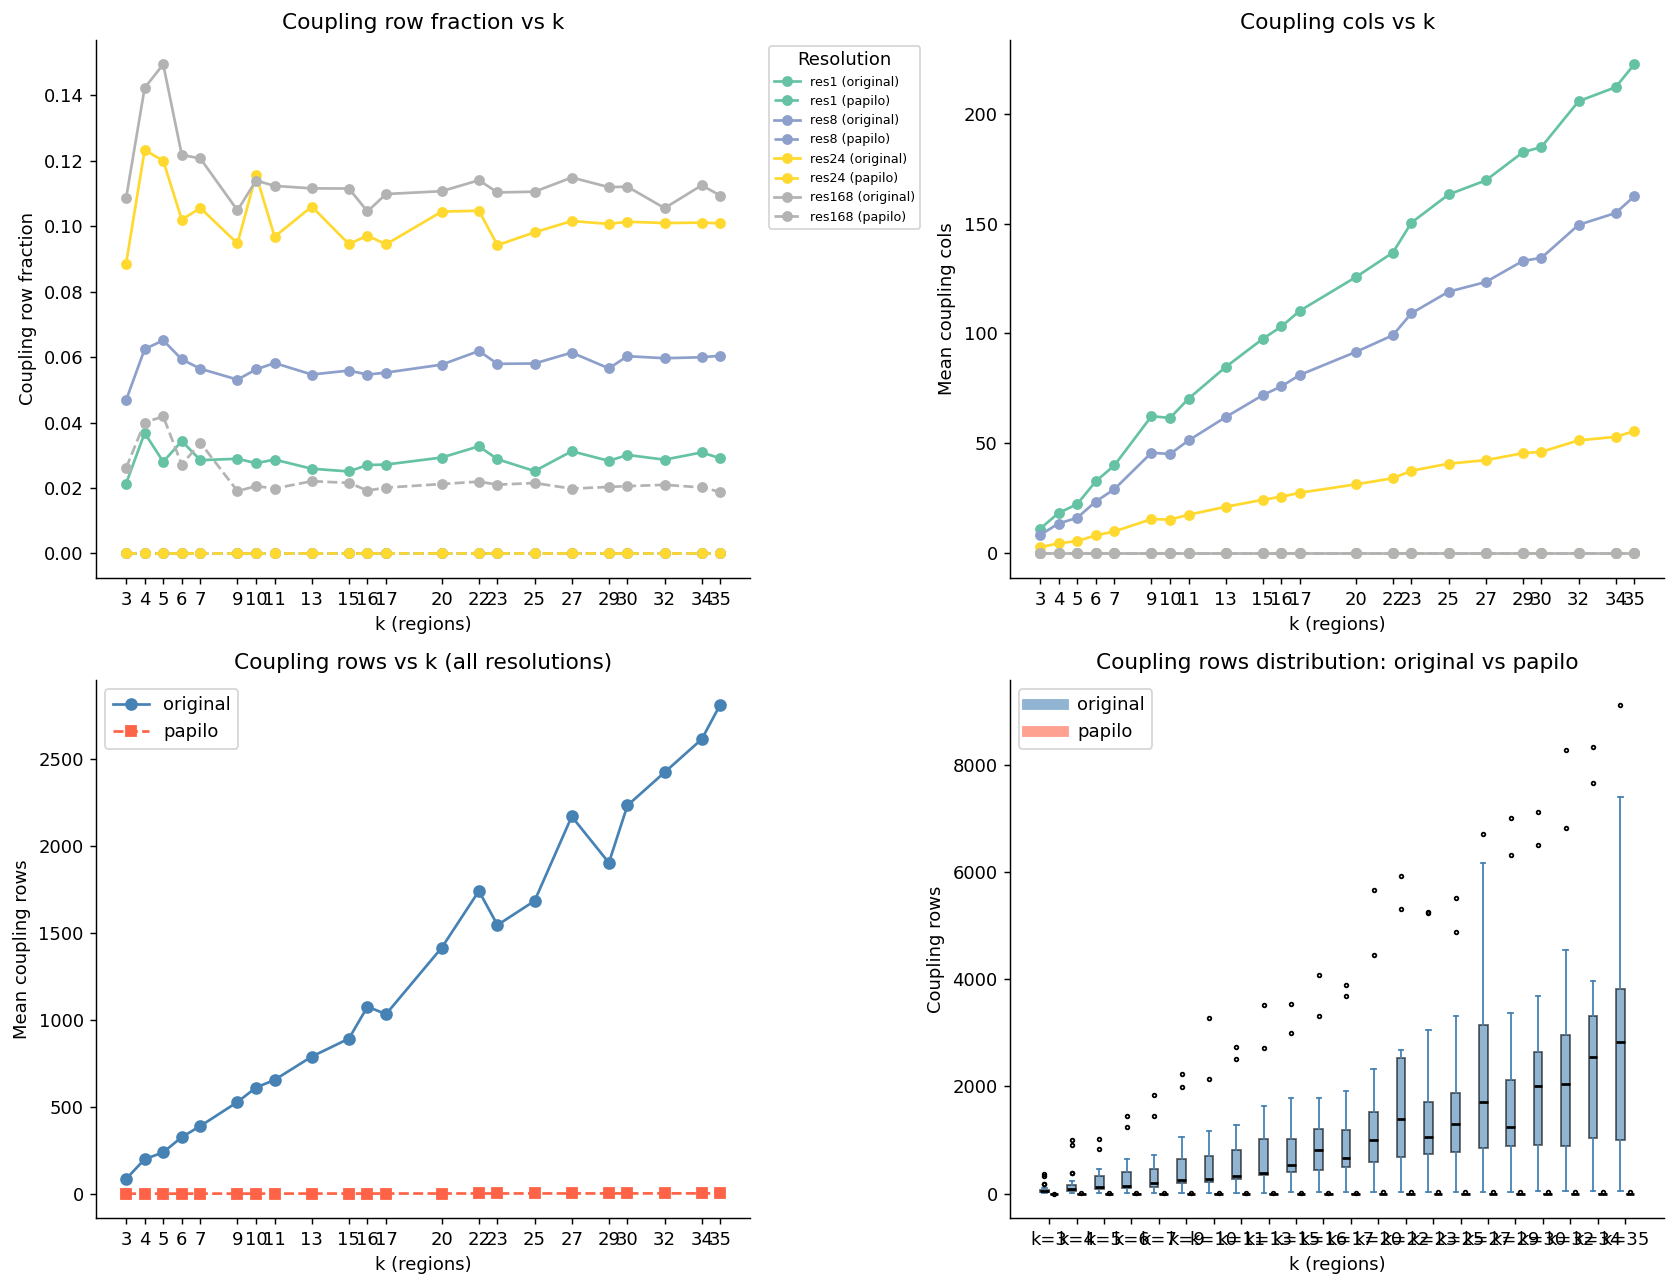

In [10]:
# --- Coupling fraction & absolute coupling vs k, by resolution ---
# Top row: coupling_row_frac (coupling rows / total rows) — normalised so models
#          of different sizes are comparable.
# Bottom row: raw coupling_rows and coupling_cols, averaged over f/t variants.
# Solid = original, dashed = papilo.

resolutions = sorted(df["res"].unique())
ks_ordered  = sorted(df["k"].unique())
res_cmap    = cm.get_cmap("Set2", len(resolutions))
res_colors  = {r: res_cmap(i) for i, r in enumerate(resolutions)}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

panels = [
    (axes[0, 0], "coupling_row_frac", "Coupling row fraction (coupling / total rows)"),
    (axes[0, 1], "coupling_cols",     "Coupling cols (abs)"),
    (axes[1, 0], "coupling_rows",     "Coupling rows (abs)"),
    (axes[1, 1], "coupling_rows",     "Coupling rows by resolution"),  # reused for boxplot below
]

# Top-left: coupling fraction vs k, by resolution
for res in resolutions:
    for source, ls in [("original", "-"), ("papilo", "--")]:
        sub = (
            df[(df["res"] == res) & (df["source"] == source)]
            .groupby("k")["coupling_row_frac"].mean()
            .reindex(ks_ordered)
        )
        axes[0, 0].plot(sub.index, sub.values, color=res_colors[res], linestyle=ls,
                        marker="o", markersize=5, label=f"res{res} ({source})")
axes[0, 0].set_xlabel("k (regions)")
axes[0, 0].set_ylabel("Coupling row fraction")
axes[0, 0].set_title("Coupling row fraction vs k")
axes[0, 0].set_xticks(ks_ordered)
axes[0, 0].legend(title="Resolution", fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")

# Top-right: coupling_cols vs k, by resolution
for res in resolutions:
    for source, ls in [("original", "-"), ("papilo", "--")]:
        sub = (
            df[(df["res"] == res) & (df["source"] == source)]
            .groupby("k")["coupling_cols"].mean()
            .reindex(ks_ordered)
        )
        axes[0, 1].plot(sub.index, sub.values, color=res_colors[res], linestyle=ls,
                        marker="o", markersize=5, label=f"res{res} ({source})")
axes[0, 1].set_xlabel("k (regions)")
axes[0, 1].set_ylabel("Mean coupling cols")
axes[0, 1].set_title("Coupling cols vs k")
axes[0, 1].set_xticks(ks_ordered)

# Bottom-left: coupling_rows vs k, both sources overlaid (no resolution split)
for source, ls, marker in [("original", "-", "o"), ("papilo", "--", "s")]:
    sub = df[df["source"] == source].groupby("k")["coupling_rows"].mean().reindex(ks_ordered)
    axes[1, 0].plot(sub.index, sub.values, linestyle=ls, marker=marker,
                    markersize=6, label=source, color="steelblue" if source == "original" else "tomato")
axes[1, 0].set_xlabel("k (regions)")
axes[1, 0].set_ylabel("Mean coupling rows")
axes[1, 0].set_title("Coupling rows vs k (all resolutions)")
axes[1, 0].set_xticks(ks_ordered)
axes[1, 0].legend()

# Bottom-right: coupling rows distribution as boxplot per k, both sources side-by-side
ax = axes[1, 1]
width = 0.35
x = np.arange(len(ks_ordered))
for offset, source, color in [(-width / 2, "original", "steelblue"), (width / 2, "papilo", "tomato")]:
    data_by_k = [
        df[(df["source"] == source) & (df["k"] == k)]["coupling_rows"].values
        for k in ks_ordered
    ]
    bp = ax.boxplot(data_by_k, positions=x + offset, widths=width * 0.9,
                    patch_artist=True, manage_ticks=False,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color="black", lw=1.5),
                    whiskerprops=dict(color=color), capprops=dict(color=color),
                    flierprops=dict(marker=".", color=color, markersize=4))
    ax.plot([], [], color=color, label=source, linewidth=6, alpha=0.6)  # legend proxy
ax.set_xticks(x)
ax.set_xticklabels([f"k={k}" for k in ks_ordered])
ax.set_xlabel("k (regions)")
ax.set_ylabel("Coupling rows")
ax.set_title("Coupling rows distribution: original vs papilo")
ax.legend()

fig.tight_layout()
plt.show()